In [1]:
# !pip install numpy.typing
# !pip install tensorflow
# !pip install tensorflow.python
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0 --force-reinstall

### Ensuring reproducibility

In [2]:
import os
import random
import numpy as np
import tensorflow as tf



### Libraries

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, recall_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, roc_auc_score, cohen_kappa_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
import keras_tuner as kt
from tensorflow.keras import regularizers
from keras_tuner import HyperModel, RandomSearch
import shap

## Load data

In [4]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
# df = pd.read_csv('/workspaces/malnutrition/Dataset/ch.csv')
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,status,province_Gandaki Province,province_Karnali Province,province_Province 1,province_Province 2,province_Province 5,province_Sudoorpaschim Province
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


### Train-test Split

In [5]:
X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2413})
After SMOTE:  Counter({0: 2828, 1: 2828})


# Artificial Neural Network

### Base model

In [7]:
# Ensuring reproducibility
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

In [8]:
# Define model architecture
ann = Sequential([
    Input(shape=(X_train_sm.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # For binary classification
])

# Compile the model
ann.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='binary_crossentropy',
    metrics=['accuracy', Recall(name='recall')]
)

# Use EarlyStopping with internal validation split
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = ann.fit(
    X_train_sm, y_train_sm,
    validation_split=0.20,  # 15% of training data used for validation
    shuffle=True,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
283/283 [==============================] - 2s 3ms/step - loss: 0.6168 - accuracy: 0.6653 - recall: 0.5861 - val_loss: 0.5295 - val_accuracy: 0.7403 - val_recall: 0.7692
Epoch 2/100
283/283 [==============================] - 1s 2ms/step - loss: 0.5629 - accuracy: 0.7292 - recall: 0.6405 - val_loss: 0.5394 - val_accuracy: 0.7102 - val_recall: 0.6701
Epoch 3/100
283/283 [==============================] - 1s 2ms/step - loss: 0.5460 - accuracy: 0.7339 - recall: 0.6114 - val_loss: 0.5243 - val_accuracy: 0.6935 - val_recall: 0.6467
Epoch 4/100
283/283 [==============================] - 1s 2ms/step - loss: 0.5432 - accuracy: 0.7354 - recall: 0.6249 - val_loss: 0.5777 - val_accuracy: 0.6731 - val_recall: 0.5724
Epoch 5/100
283/283 [==============================] - 1s 2ms/step - loss: 0.5342 - accuracy: 0.7383 - recall: 0.6099 - val_loss: 0.5186 - val_accuracy: 0.6890 - val_recall: 0.6415
Epoch 6/100
283/283 [==============================] - 1s 2ms/step - loss: 0.5312 - accuracy: 0

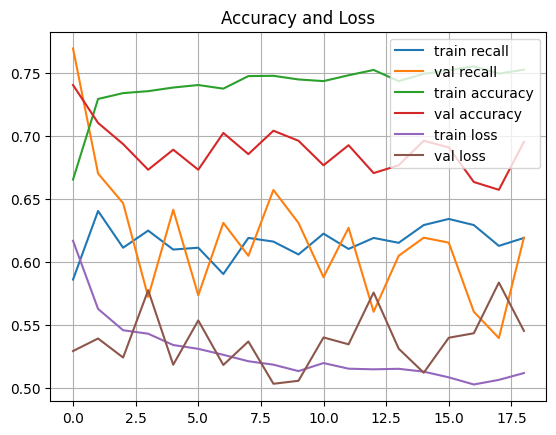

In [9]:
# Accuracies and losses
plt.plot(history.history['recall'], label='train recall')
plt.plot(history.history['val_recall'], label='val recall')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.grid()
plt.title('Accuracy and Loss')
plt.show()

The training and validation curves in the plot indicate that the model is learning effectively, with both training and validation accuracy steadily improving and converging around 0.72. The training and validation loss curves also show expected behavior, with the training loss decreasing smoothly and validation loss initially dropping before slightly rising, suggesting a mild risk of overfitting after around 20 epochs. The recall on the training set gradually improves, indicating the model is increasingly successful at identifying malnourished children during training. However, the validation recall fluctuates significantly across epochs, which may point to model adjustments.

In [10]:
y_pred = (ann.predict(X_test) > 0.5).astype("int")
print(classification_report(y_test, y_pred, digits=3))

41/41 [==============================] - 0s 957us/step
              precision    recall  f1-score   support

           0      0.740     0.779     0.759       707
           1      0.724     0.679     0.701       604

    accuracy                          0.733      1311
   macro avg      0.732     0.729     0.730      1311
weighted avg      0.733     0.733     0.732      1311



In [11]:
# Get predicted probabilities
y_probas = ann.predict(X_test).ravel()  # flatten the output to 1D

# Compute average precision
ap_score = average_precision_score(y_test, y_probas)
print(f'Average Precision: {ap_score:.3f}')

41/41 [==============================] - 0s 896us/step
Average Precision: 0.825


# Hyperparameter Tuning

In [12]:
# Ensuring reproducibility
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

In [13]:
# Define a model builder function
def build_model(hp):
    ann = Sequential()

    # Add input layer
    ann.add(Input(shape=(X_train_sm.shape[1],)))

    # First dense layer: tune number of neurons and dropout
    ann.add(Dense(
        hp.Int('units_1', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    ann.add(Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)))

    # Second dense layer
    ann.add(Dense(
        hp.Int('units_2', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    ann.add(Dropout(hp.Float('dropout_2', 0.1, 0.3, step=0.1)))

    # Output layer
    ann.add(Dense(1, activation='sigmoid'))

    # Compile with tunable learning rate
    ann.compile(
        optimizer=Adam(hp.Choice('learning_rate', [0.001, 0.0005, 0.005])),
        loss='binary_crossentropy',
        metrics=['accuracy', Recall()]
    )

    return ann

In [14]:
# Define tuner
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_recall", direction="max"),  # Focus on recall
    max_trials=5,
    executions_per_trial=1,
    overwrite=True,
    directory='kt_dir',
    project_name='malnutrition_tuning'
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Run the search
tuner.search(
    X_train_sm, y_train_sm,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Trial 5 Complete [00h 00m 33s]
val_recall: 0.6831812262535095

Best val_recall So Far: 0.7705345749855042
Total elapsed time: 00h 02m 20s


In [17]:
ann_tuned = tuner.get_best_models(1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]

# Re-compile the best model before using it
ann_tuned.compile(
    optimizer=Adam(learning_rate=best_hps.get('learning_rate')),
    loss='binary_crossentropy',
    metrics=[Recall(name="recall")]
)

In [19]:
# Evaluate or predict
y_pred_tuned = (ann_tuned.predict(X_test) > 0.5).astype("int")
print("Classification Report:\n", classification_report(y_test, y_pred_tuned, digits=3))

41/41 [==============================] - 0s 977us/step
Classification Report:
               precision    recall  f1-score   support

           0      0.762     0.672     0.714       707
           1      0.663     0.755     0.706       604

    accuracy                          0.710      1311
   macro avg      0.713     0.713     0.710      1311
weighted avg      0.717     0.710     0.710      1311



In [ ]:
print("Best Hyperparameters:")
print(f"units_1: {best_hps.get('units_1')}")
print(f"dropout_1: {best_hps.get('dropout_1')}")
print(f"units_2: {best_hps.get('units_2')}")
print(f"dropout_2: {best_hps.get('dropout_2')}")
print(f"learning_rate: {best_hps.get('learning_rate')}")

Best Hyperparameters:
units_1: 96
dropout_1: 0.2
units_2: 64
dropout_2: 0.1
learning_rate: 0.001


In [22]:
# Get predicted probabilities
y_probas_tune = ann_tuned.predict(X_test).ravel()  # flatten the output to 1D

# Compute average precision
ap_score = average_precision_score(y_test, y_probas_tune)
print(f'Average Precision (ANN): {ap_score:.3f}')

41/41 [==============================] - 0s 1ms/step
Average Precision (ANN): 0.806


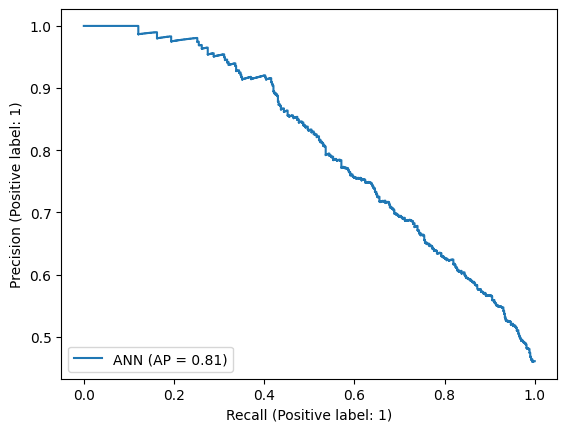

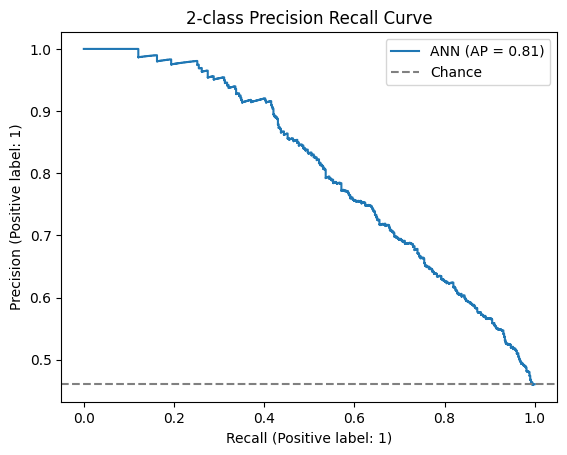

In [23]:
# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas_tune,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()

In [24]:
# Recall on base model
y_pred = (ann.predict(X_train_sm) > 0.5).astype("int").reshape(-1)
train_recall = recall_score(y_train_sm, y_pred)
print(f"Recall on Training set (Base Model): {train_recall:.3f}")

# Recall on tuned model
y_pred_tune = (ann_tuned.predict(X_train_sm) > 0.5).astype("int").reshape(-1)
train_recall_tuned = recall_score(y_train_sm, y_pred_tune)
print(f"Recall on Training set (Tuned Model): {train_recall_tuned:.3f}")


177/177 [==============================] - 0s 1ms/step
Recall on Training set (Base Model): 0.681
177/177 [==============================] - 0s 1ms/step
Recall on Training set (Tuned Model): 0.760


In [25]:
auc = roc_auc_score(y_test, y_probas)
print(f"AUC: {auc:.3f}")

auc_tune = roc_auc_score(y_test, y_probas_tune)
print(f"AUC: {auc_tune:.3f}")

AUC: 0.824
AUC: 0.799


In [28]:
# Get binary predictions from base model
y_pred = (ann.predict(X_test) > 0.5).astype("int").ravel()
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa (Base Model): {kappa:.3f}")

# Get binary predictions from tuned model
y_pred_tune = (ann_tuned.predict(X_test) > 0.5).astype("int").ravel()
kappa_tune = cohen_kappa_score(y_test, y_pred_tune)
print(f"Cohen's Kappa (Tuned Model): {kappa_tune:.3f}")


41/41 [==============================] - 0s 930us/step
Cohen's Kappa (Base Model): 0.460
41/41 [==============================] - 0s 977us/step
Cohen's Kappa (Tuned Model): 0.423


41/41 [==============================] - 0s 1ms/step


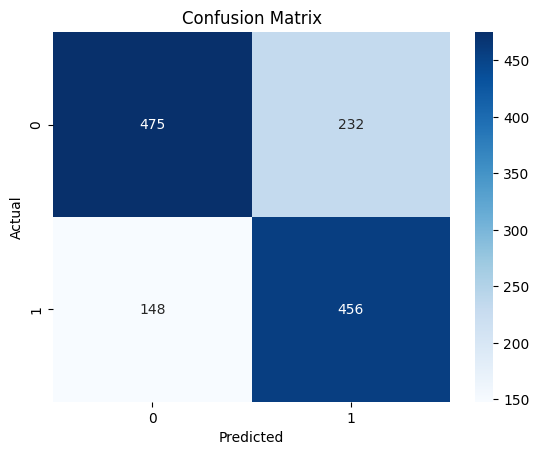

In [29]:
# Get binary predictions
y_pred_tune = (ann_tuned.predict(X_test) > 0.5).astype("int").ravel()

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

27/27 [==============================] - 0s 645us/step


PermutationExplainer explainer:   2%|▏         | 2/100 [00:00<?, ?it/s]

37/37 [==============================] - 0s 922us/step


PermutationExplainer explainer:   4%|▍         | 4/100 [00:12<01:28,  1.08it/s]

33/33 [==============================] - 0s 739us/step


...

PermutationExplainer explainer:  99%|█████████▉| 99/100 [02:55<00:01,  1.70s/it]

30/30 [==============================] - 0s 565us/step


PermutationExplainer explainer: 100%|██████████| 100/100 [02:56<00:00,  1.67s/it]

31/31 [==============================] - 0s 493us/step


PermutationExplainer explainer: 101it [02:58,  1.80s/it]                         
C:\Users\dbastola2022\AppData\Local\Temp\ipykernel_3812\4272692237.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:100])


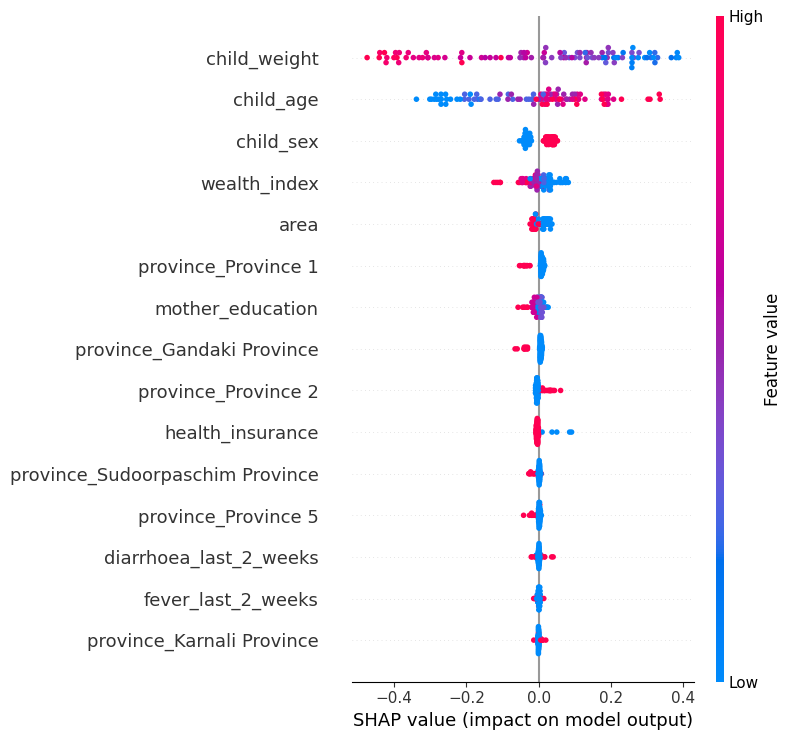

In [ ]:
explainer = shap.Explainer(ann_tuned.predict, X_train_sm)
shap_values = explainer(X_test[:100])  # Subset for speed

# Summary plot
shap.summary_plot(shap_values, X_test[:100])


### Additional

41/41 [==============================] - 0s 945us/step


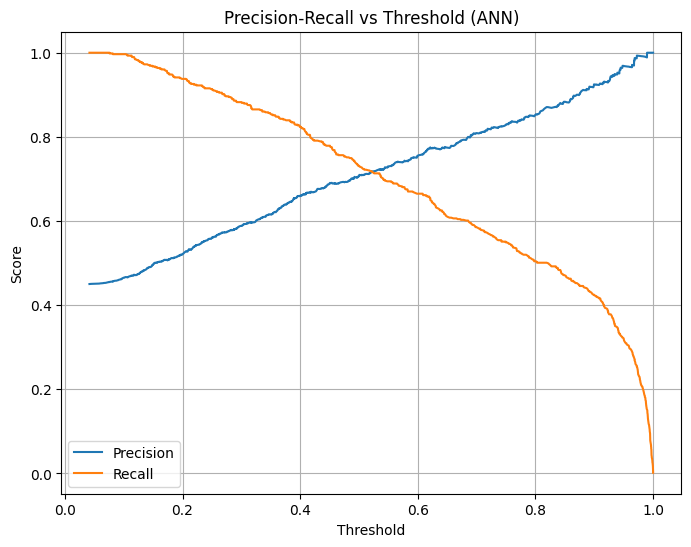

In [ ]:
# Get predicted probabilities from Keras model
y_probas = ann_tuned.predict(X_test).flatten()

# Precision-Recall calculation
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold (ANN)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.82      0.65      0.73       707
           1       0.66      0.82      0.73       579

    accuracy                           0.73      1286
   macro avg       0.74      0.74      0.73      1286
weighted avg       0.75      0.73      0.73      1286


